
# Volume 2: Reinforcement Learning 1 - Gymnasium



<Name\>
<Class\>
<Date\>





In [2]:
import gymnasium as gym
import numpy as np
import random
from matplotlib import pyplot as plt
from IPython import display

# Problem 1

*   Implement `random_blackjack()`.
*   Run the game 50,000 times and print the percentage of games won.



In [ ]:
# Problem 1
def random_blackjack(n=50000):
    """ Play a random game of Blackjack. Determine the percentage 
        the player wins out of n times.
    Parameters:
        n (int): number of episodes
    Returns:
        percent (float): percentage that the player wins
    """
    def play_game(env):
        env.reset()
        done = False
        while True: # Go until the game finishes
            if done: # If it's finished
                return reward
            _, reward, done, _, _ = env.step(env.action_space.sample()) # Take another step
    
    wins = 0
    for _ in range(n):
        env = gym.make('Blackjack-v1')
        result = play_game(env)
        if result == 1:
            wins += 1
        env.close()
    
    return wins / n

    

In [4]:
random_blackjack()

28.396

# Problem 2

* Implement `blackjack()`.
* For `n` = 1, 2, ..., 21, plot the win percentage after 10,000 games of Blackjack.
* Identify which value(s) of `n` gives the highest win rate.

In [5]:
# Problem 2
def blackjack(n=11):
    """ Play blackjack with naive algorithm.
    Parameters:
        n (int): maximum accepted player hand
    Return:
        percent (float): percentage wins over 10_000 episodes
    """
    def play_game(env, n):
        obs, _ = env.reset()
        done = False
        while True: # Go until the game finishes
            if done: # If it's finished
                return reward
            elif obs[0] > n:
                obs, reward, done, _, _ = env.step(0) # Fold
            else:
                obs, reward, done, _, _ = env.step(1) # Take another step
    
    wins = 0
    for _ in range(10000):
        env = gym.make('Blackjack-v1')
        result = play_game(env, n)
        if result == 1:
            wins += 1
        env.close()
    
    return wins / 100



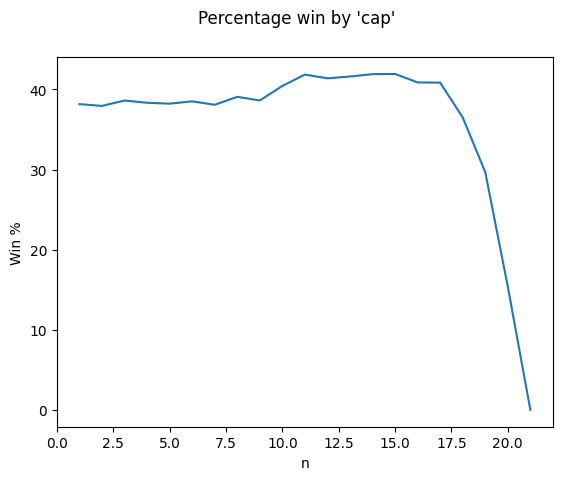

In [ ]:
x = []
y = []

for i in range(21):
    x.append(i + 1)
    y.append(blackjack(i+1)) # Result of folding at i+1

plt.plot(x, y)
plt.xlabel("n")
plt.ylabel("Win %")
plt.suptitle("Percentage win by 'cap'")
plt.show()

Looks like it's around 12 to 14

# Problem 3

* Implement `cartpole()`.
* Render the game and run your function once.
* Run Cartpole 100 times (without rendering) and print out the average number of steps before it terminates.

In [ ]:
# Problem 3
def cartpole(render=False):
    """ Solve CartPole-v1 by checking the velocity of the tip 
        of the pole.
    Parameters: 
        render (bool): If True, render environment at each step
    Return:
        iterations (integer): number of timesteps to solve the environment
    """
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    obs, _ = env.reset()
    done = False # For first step in while loop
    count = 0
    img = plt.imshow(env.render()) # Show
    while not done:
        if obs[3] > 0:
            obs, reward, done, _, _ = env.step(1) # If it's moving left, move left
        else:
            obs, reward, done, _, _ = env.step(0) # If it's moving right, move right
        count += 1
        if render:
            img.set_data(env.render())
            display.display(plt.gcf())
            display.clear_output(wait=True)
    return count


/usr/local/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


190

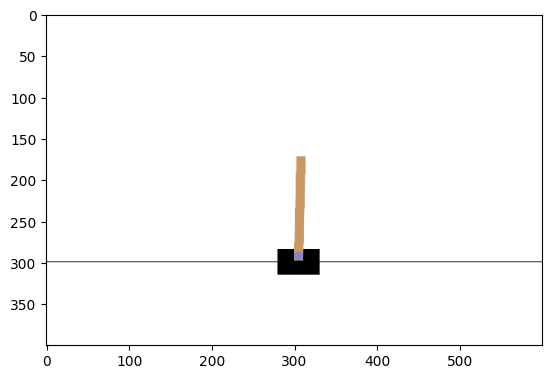

In [8]:
cartpole()

np.float64(203.37)

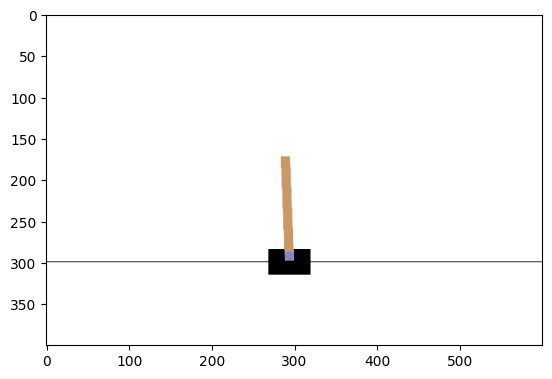

In [9]:
idk = []
for _ in range(100):
    idk.append(cartpole())

np.mean(idk)

# Problem 4

* Implement `car()`.
* Render the game and run your function once.
* Run MountainCar 100 times (without rendering) and print out the average number of steps before it terminates.

In [10]:
# Problem 4
def car(render=False):
    """ Solve MountainCar-v0 by checking the position of the car.
    Parameters: 
        render (bool): If True, render environment at each step
    Return:
        iterations (integer): number of timesteps or time-periods to solve the environment
    """
    env = gym.make('MountainCar-v0', render_mode='rgb_array')
    obs, _ = env.reset()
    done = False
    top_of_left = False
    obs, reward, done, _, _ = env.step(2)
    count = 0
    img = plt.imshow(env.render())
    while not done:
        count += 1
        x, v = obs
        if x == -1.2:
            top_of_left = True
        if not top_of_left:
            if v < 0:
                obs, reward, done, _, _ = env.step(0)
            if v > 0:
                obs, reward, done, _, _ = env.step(2)
        elif top_of_left:
            obs, reward, done, _, _ = env.step(2)
        if render:
            img.set_data(env.render())
            display.display(plt.gcf())
            display.clear_output(wait=True)
    return count

113

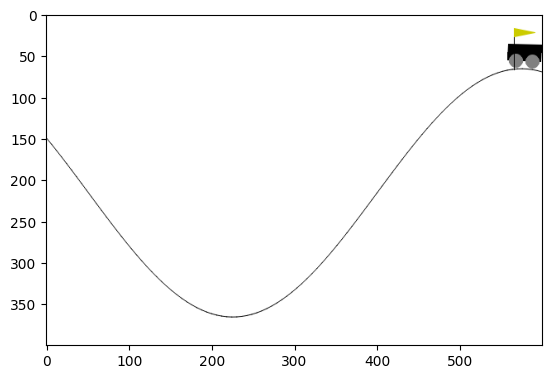

In [11]:
car(True)

np.float64(119.39)

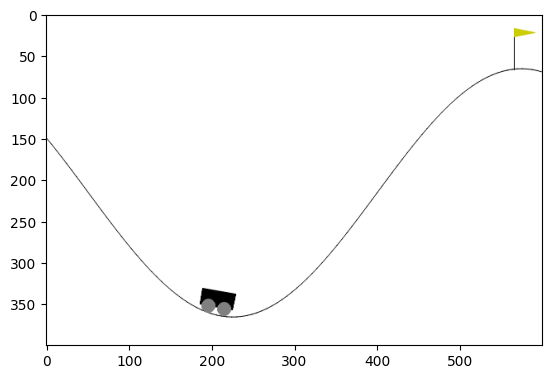

In [12]:
idk = []
for _ in range(100):
    idk.append(car())

np.mean(idk)

# Problem 5

* Create the function epsilon_decay according to the linear decay model.

In [ ]:
def epsilon_decay(episode, N, epsilon_start=1.0, epsilon_end=1e-6):
    """ Decay epsilon value over time according to a linear decay.
    Parameters:
        episode (int): current episode number
        N (int): total number of episodes
        epsilon_start (float): starting epsilon value
        epsilon_end (float): ending epsilon value
    Returns:
        epsilon (float): decayed epsilon value
    """
    
    delta = (epsilon_start - epsilon_end) / N # Equation 1
    return epsilon_start - (delta * (episode - 1)) # Equation 2

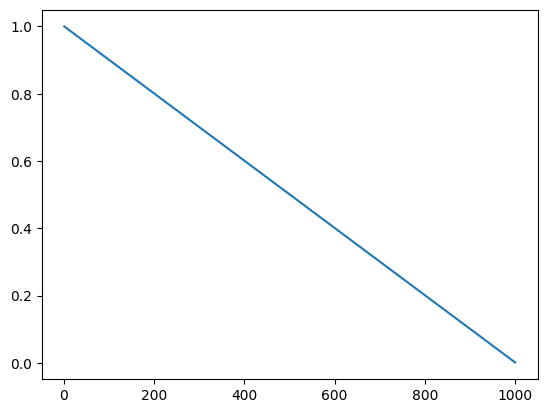

In [ ]:
N = 1000 # Fiddle with this variable
idk = np.linspace(1, N, N) # Wanted a range here but my def threw a fit
plt.plot(idk, epsilon_decay(idk, N))
plt.show()

## Helper Function for Problem 6 (Q-learning algorithm)

In [ ]:
def qlearn(env, alpha=.1, gamma=.6, epsilon=.1, N=70_000, decay=False):
    """ Use the Q-learning algorithm to find qvalues.
    Parameters:
        env (str): environment name (i.e. gym environment name)
        alpha (float): learning rate
        gamma (float): discount factor
        epsilon (float): epsilon value for epsilon-greedy algo
        N (int): number of episodes to train for
        decay (bool): whether to decay epsilon according to epsilon_decay
    Returns:
        q_table (ndarray nxm): the Q(s,a) approximation values generated by Q-learning
    """
    
    # Make environment
    env = gym.make(env)  
    # Make Q-table
    q_table = np.zeros((env.observation_space.n, env.action_space.n))

    # Train for N episodes
    for i in range(1,N+1):
    
        # Reset state and get initial state; Initialize penalties, reward, and done
        curr_state, info = env.reset() 
        penalties, reward, = 0,0
        done = False
        
        # Get epsilon value
        if not decay:
            curr_epsilon = epsilon
        else:
            curr_epsilon = epsilon_decay(i, N)
            
        # Keep going until the terminal state is reached
        while not done:
            
            # Employ the epsilon=greedy algorithm
            if random.uniform(0,1) < curr_epsilon: # Explore
                curr_action = env.action_space.sample()
            else:                                  # Exploit
                curr_action = np.argmax(q_table[curr_state])

            # Take action and get new state and reward
            next_state, reward, done, truncated, info = env.step(curr_action)

            # Calculate new qvalue
            old_value = q_table[curr_state,curr_action]
            next_max = (q_table[next_state]).max()
            new_value = (1-alpha) * old_value + alpha * (reward + gamma * next_max)
            q_table[curr_state, curr_action] = new_value

            # Check if penalty is made; specific to Taxi env
            if reward == -10:
                penalties += 1

            # Get next observation
            curr_state = next_state

        # Print episode number
        if i % 100 == 0:
            display.clear_output(wait=True)
            print("Training model...")
            print(f"Episode: {i}")

    env.close()
    print("Training finished.")
    return q_table, penalties

# Problem 6

* Initialize the "`Taxi-v3`" environment (without rendering), act randomly until it terminates, and print the total reward
* Render the "`Taxi-v3`" environment, use the Q-table to act optimally until it terminates, and print the total reward. Use a constant epsilon value, and do not decay.
* Render the "`Taxi-v3`" environment, use the Q-table, using a decaying epsilon value, to act optimally until it terminates, and print the total reward.
* Implement `taxi()`, then use it to compare the constant epsilon and decaying epsilon Q-tables and write a brief analysis of the results. Note the given return values in the function are not necessary but can help you compare the two methods.


In [67]:
# Random
env = gym.make('Taxi-v3', render_mode='rgb_array')
obs, _ = env.reset()
reward = 0
while not done:
    obs, reward, done, _, _ = env.step(env.action_space.sample())
reward

20

In [68]:
# Create Q-table for constant epsilon
q_table = qlearn("Taxi-v3")


Training model...
Episode: 70000
Training finished.


20


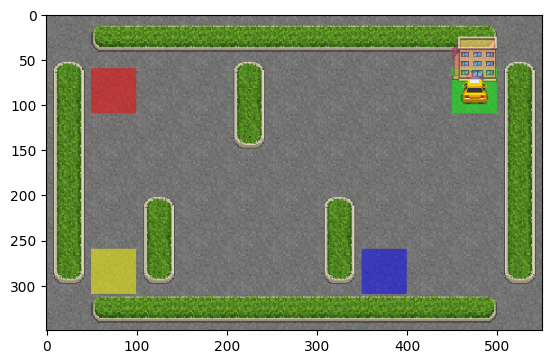

In [96]:
# Run the Taxi game here for Q-table with constant epsilon
env = gym.make("Taxi-v3", render_mode='rgb_array')
obs, _ = env.reset()
done = False
img = plt.imshow(env.render())
while not done:
    obs, reward, done, _, _ = env.step(np.argmax(q_table[0][obs,:]))
    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)
print(reward)

In [100]:
# Create Q-table for decaying epsilon
q_table_decay = qlearn("Taxi-v3", decay=True)

Training model...
Episode: 70000
Training finished.


20


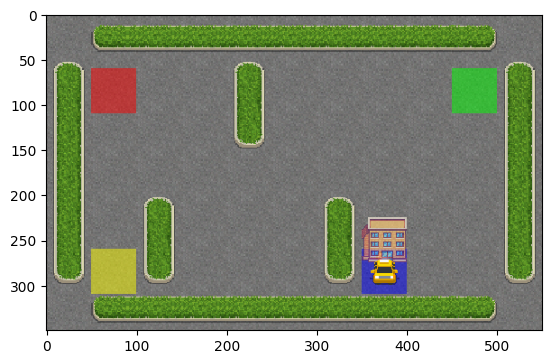

In [101]:
# Run the Taxi game here for Q-table with decaying epsilon
env = gym.make("Taxi-v3", render_mode='rgb_array')
obs, _ = env.reset()
done = False
img = plt.imshow(env.render())
while not done:
    obs, reward, done, _, _ = env.step(np.argmax(q_table_decay[0][obs,:]))
    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)
print(reward)

In [104]:
def taxi(q_table, q_table_decay):
    """  Compare the Q-learning algorithm with a constant epsilon value to the one trained using a 
    decaying epsilon value.
    
    Parameters:
        q_table (ndarray nxm): table of qvalues that used constant epsilon
        q_table_decay (ndarray nxm): table of qvalues that used a decaying epsilon
    Returns:
        constant_reward (float): mean reward of 1000 episodes of Q-learning algorithm using constant epsilon
        decay_reward (float): mean reward of 1000 episodes of Q-learning algorithm using decayed epsilon
    """
    N = 1000
    constant_reward = []
    decay_reward = []
    for _ in range(N):
        env = gym.make("Taxi-v3", render_mode='rgb_array')
        obs, _ = env.reset()
        done = False
        while not done:
            obs, reward, done, _, _ = env.step(np.argmax(q_table[0][obs,:]))
        constant_reward.append(reward)

        env = gym.make("Taxi-v3", render_mode='rgb_array')
        obs, _ = env.reset()
        done = False
        while not done:
            obs, reward, done, _, _ = env.step(np.argmax(q_table_decay[0][obs,:]))
        decay_reward.append(reward)
    return sum(constant_reward) / N, sum(decay_reward) / N

taxi(q_table, q_table_decay)

(20.0, 20.0)

### Analysis of constant epsilon and decaying epsilon Q-tables here

It didn't seem to make any difference in output. But it was a really small sample space so I imagine extra exploring didn't really do much. BUT I feel like the decaying epsilon table took way less time to train.